##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
from google.colab import files
uploaded = files.upload()

Saving UCF11_updated_mpg.zip to UCF11_updated_mpg.zip


In [2]:
!unzip -q UCF11_updated_mpg.zip -d /content/UCF11_data

In [3]:
DATASET_DIR = "/content/UCF11_data/UCF11_updated_mpg"

In [6]:
!pip install -q opencv-python tqdm

In [7]:
import os
import cv2
import numpy as np
import random
import tensorflow as tf

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed, Conv2D, MaxPooling2D, Flatten,
    LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 64
SEQUENCE_LENGTH = 20
TEST_SIZE = 0.2
BATCH_SIZE = 8
EPOCHS = 20

SELECTED_CLASSES = ["basketball", "biking", "tennis_swing"]

student_name = "ElafFareed"
MODEL_SAVE_PATH = f"/content/{student_name}_ucf11_model.h5"

In [13]:
def get_class_video_paths(dataset_dir, selected_classes):
    video_paths = []
    labels = []

    for class_name in selected_classes:
        class_path = os.path.join(dataset_dir, class_name)

        if not os.path.exists(class_path):
            continue

        for subfolder in os.listdir(class_path):
            sub_path = os.path.join(class_path, subfolder)

            if not os.path.isdir(sub_path):
                continue

            for file in os.listdir(sub_path):
                if file.lower().endswith(".mpg"):
                    video_paths.append(os.path.join(sub_path, file))
                    labels.append(class_name)

    return video_paths, labels


def extract_frames_from_video(video_path, sequence_length=20, img_size=64):
    cap = cv2.VideoCapture(video_path)

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return None

    frame_indices = np.linspace(0, frame_count - 1, sequence_length, dtype=int)
    target_set = set(frame_indices.tolist())

    frames = []
    current_index = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_index in target_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frame = frame.astype("float32") / 255.0
            frames.append(frame)

        current_index += 1

    cap.release()

    if len(frames) == 0:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1])

    return np.array(frames[:sequence_length])


def load_dataset(video_paths, labels, sequence_length=20, img_size=64):
    X, y, valid_paths = [], [], []

    for path, label in tqdm(list(zip(video_paths, labels)), desc="Loading videos"):
        frames = extract_frames_from_video(path, sequence_length, img_size)
        if frames is not None:
            X.append(frames)
            y.append(label)
            valid_paths.append(path)

    return np.array(X), np.array(y), valid_paths


def build_model(sequence_length, img_size, num_classes):
    model = Sequential([
        TimeDistributed(
            Conv2D(32, (3, 3), activation='relu'),
            input_shape=(sequence_length, img_size, img_size, 3)
        ),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(BatchNormalization()),

        TimeDistributed(Conv2D(64, (3, 3), activation='relu')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(BatchNormalization()),

        TimeDistributed(Conv2D(128, (3, 3), activation='relu')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(BatchNormalization()),

        TimeDistributed(Flatten()),

        LSTM(128, return_sequences=False),
        Dropout(0.5),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
video_paths, labels = get_class_video_paths(DATASET_DIR, SELECTED_CLASSES)

print("Total videos found:", len(video_paths))
print("Classes found:", sorted(set(labels)))
print("Sample paths:", video_paths[:5])

Total videos found: 453
Classes found: ['basketball', 'biking', 'tennis_swing']
Sample paths: ['/content/UCF11_data/UCF11_updated_mpg/basketball/v_shooting_20/v_shooting_20_01.mpg', '/content/UCF11_data/UCF11_updated_mpg/basketball/v_shooting_20/v_shooting_20_07.mpg', '/content/UCF11_data/UCF11_updated_mpg/basketball/v_shooting_20/v_shooting_20_04.mpg', '/content/UCF11_data/UCF11_updated_mpg/basketball/v_shooting_20/v_shooting_20_06.mpg', '/content/UCF11_data/UCF11_updated_mpg/basketball/v_shooting_20/v_shooting_20_02.mpg']


In [15]:
X, y, valid_paths = load_dataset(
    video_paths,
    labels,
    sequence_length=SEQUENCE_LENGTH,
    img_size=IMG_SIZE
)

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading videos: 100%|██████████| 453/453 [00:21<00:00, 20.64it/s]


X shape: (453, 20, 64, 64, 3)
y shape: (453,)


In [16]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

print("Classes:", label_encoder.classes_)
print("Encoded sample:", y_encoded[:10])

Classes: ['basketball' 'biking' 'tennis_swing']
Encoded sample: [0 0 0 0 0 0 0 0 0 0]


In [17]:
X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    X, y_cat, valid_paths,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_encoded
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (362, 20, 64, 64, 3) (362, 3)
Test shape: (91, 20, 64, 64, 3) (91, 3)


In [18]:
num_classes = len(label_encoder.classes_)
model = build_model(SEQUENCE_LENGTH, IMG_SIZE, num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 62, 62, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 31, 31, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 31, 31, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 29, 29, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 14, 14, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 20, 14, 14, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 20, 12, 12,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 20, 6, 6, 128)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 20, 6, 6, 128)  │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 20, 4608)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │     2,425,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,527,939 (9.64 MB)

 Trainable params: 2,527,491 (9.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="/content/best_temp_model.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5121 - loss: 1.1165

37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 211ms/step - accuracy: 0.5190 - loss: 1.0441 - val_accuracy: 0.6575 - val_loss: 0.8644
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.6159 - loss: 0.8153 - val_accuracy: 0.6575 - val_loss: 0.8664
Epoch 3/20
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7035 - loss: 0.6769

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.6920 - loss: 0.6858 - val_accuracy: 0.7397 - val_loss: 0.6763
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8083 - loss: 0.5106

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.7993 - loss: 0.5171 - val_accuracy: 0.7671 - val_loss: 0.6442
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8547 - loss: 0.4452 - val_accuracy: 0.7671 - val_loss: 0.5420
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.8616 - loss: 0.4351 - val_accuracy: 0.7671 - val_loss: 0.5488
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.8443 - loss: 0.4055 - val_accuracy: 0.7260 - val_loss: 0.6906
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8659 - loss: 0.3913

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.8651 - loss: 0.3746 - val_accuracy: 0.7808 - val_loss: 0.7102
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8439 - loss: 0.4008

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.8478 - loss: 0.3731 - val_accuracy: 0.7945 - val_loss: 0.5564
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8789 - loss: 0.3414 - val_accuracy: 0.7397 - val_loss: 0.7240


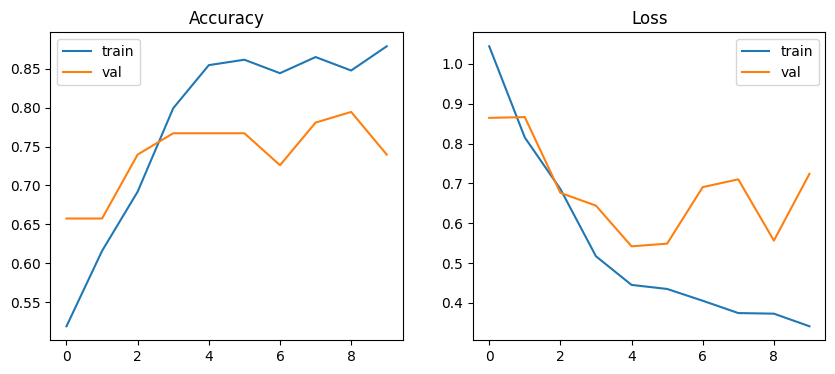

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8132 - loss: 0.4968
Test Loss: 0.4968
Test Accuracy: 0.8132


In [21]:
model.save(MODEL_SAVE_PATH)
print(f"Model saved as {MODEL_SAVE_PATH}")

Model saved as /content/ElafFareed_ucf11_model.h5


In [22]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files
uploaded = files.upload()

Saving v_biking_15_02.mpg to v_biking_15_02.mpg
Saving v_shooting_09_02.mpg to v_shooting_09_02.mpg
Saving v_tennis_16_03.mpg to v_tennis_16_03.mpg


In [25]:
def predict_video_class(video_path, model, label_encoder, sequence_length=20, img_size=64):
    frames = extract_frames_from_video(video_path, sequence_length, img_size)
    if frames is None:
        return None, None

    input_data = np.expand_dims(frames, axis=0)
    probs = model.predict(input_data, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    confidence = float(probs[pred_idx])

    return pred_label, confidence

In [32]:
youtube_test_videos = {
    "basketball": "/content/v_shooting_09_02.mpg",
    "biking": "/content/v_biking_15_02.mpg",
    "tennis_swing": "/content/v_tennis_16_03.mpg"
}

for true_class, video_path in youtube_test_videos.items():
    pred_label, confidence = predict_video_class(
        video_path, model, label_encoder,
        sequence_length=SEQUENCE_LENGTH,
        img_size=IMG_SIZE
    )

    print(f"Video: {video_path}")
    print(f"Expected: {true_class}")
    print(f"Predicted: {pred_label}")
    print(f"Confidence: {confidence:.2f}")
    print("-" * 40)

Video: /content/v_shooting_09_02.mpg
Expected: basketball
Predicted: biking
Confidence: 0.45
----------------------------------------
Video: /content/v_biking_15_02.mpg
Expected: biking
Predicted: biking
Confidence: 0.89
----------------------------------------
Video: /content/v_tennis_16_03.mpg
Expected: tennis_swing
Predicted: tennis_swing
Confidence: 0.97
----------------------------------------


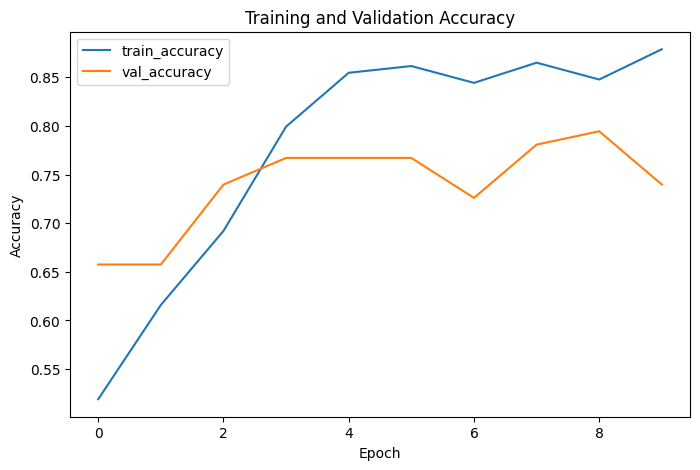

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

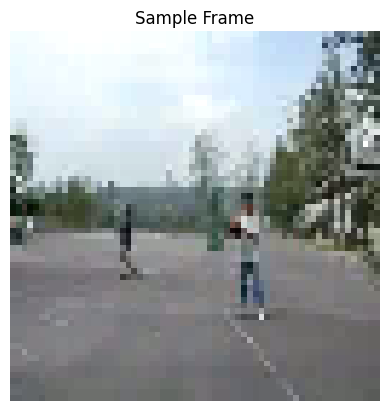

In [30]:
import matplotlib.pyplot as plt

sample = X[0]
plt.imshow(sample[0])
plt.title("Sample Frame")
plt.axis("off")
plt.show()